In [1]:
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
import random
from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

import yfinance as yf

def normal_auc(u=0, sd=1, fill_min=0, fill_max=0,title=None):
    mn=u-(sd*4)
    mx=u+(sd*4)
    x = np.linspace(mn, mx, 100)
    y = stats.norm.pdf(x, loc=u, scale=sd)
    fig, ax = plt.subplots(figsize=(8, 5))
    p=sns.lineplot(x=x, y=y);
    if title:
        ax.set(title=title)
    if u==0 and sd==1:
        ax.set_xticks([-4, -3, -2, -1, 0, 1, 2, 3, 4])
        ax.set_xticklabels(['-4\u03C3', '-3\u03C3', '-2\u03C3', '-\u03C3', '\u03bc', '\u03C3','2\u03C3','3\u03C3', '4\u03C3'])
    #if fill:
    #get x and y values
    df_xy=pd.DataFrame(columns=['x','y'])
    df_xy.x=x
    df_xy.y=y
    if fill_min != 'min'and fill_max !='max':
        x1 = df_xy.loc[(df_xy.x>=fill_min)&(df_xy.x<=fill_max)].x
    elif fill_min=='min' and fill_max!='max':
        x1 = df_xy.loc[df_xy.x<=fill_max].x
    elif fill_min!='min' and fill_max=='max':
        x1 = df_xy.loc[df_xy.x>=fill_min].x
    y1=df_xy.iloc[x1.index].y
    # Fill the area from 0 to each point
    ax.fill_between(x1, y1=0, y2=y1, color='#022d69', alpha=0.8, zorder=0);

def conf_int_t_data(data, conf_level):
    n=len(data)
    df=n-1
    sample_std=np.std(data, ddof=1)
    sample_mean=np.mean(data)
    #step 1 - find std error of sample dist
    sem=sample_std/np.sqrt(n)
    #step 2 - find critical t-value
    alpha=1-conf_level
    q=1-(alpha/2)
    t=stats.t.ppf(q, df)
    #step 3 - find margin of error
    me=sem*t
    #step 4 - contruct interval
    ci=(sample_mean-me, sample_mean+me)
    return ci

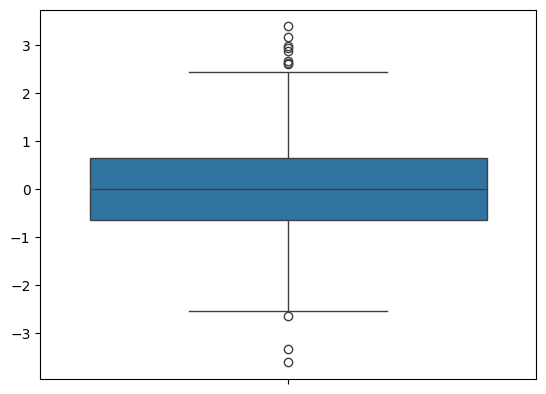

In [7]:
x=np.random.normal(loc=0, scale=1, size=1000)

sns.boxplot(y=x);

In [8]:
x=[]
for i in range(0,100):
    #100 people in the bar with net worth between 10,000 and 1,000,000
    x.append(random.randint(10000,1000000))

print('mean without bill: ', f"${np.mean(x):,.2f}")

#now add bill gates - 117,000,000,000
bill=115000000000
x.append(bill)

print('mean with bill: ', f"${np.mean(x):,.2f}")

mean without bill:  $448,526.21
mean with bill:  $1,139,057,946.74


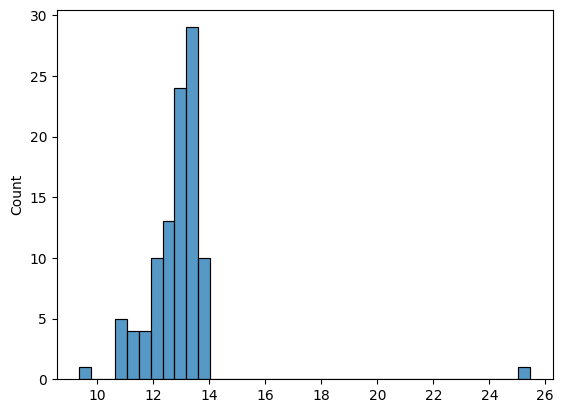

In [12]:
sns.histplot(x=[np.log(ix) for ix in x]);

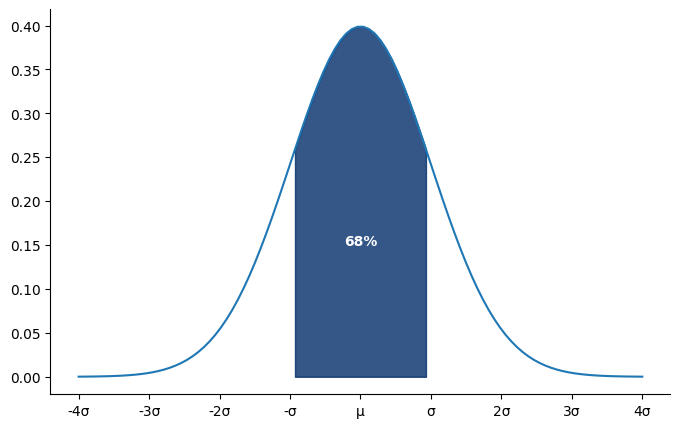

In [56]:
normal_auc(u=0, sd=1, fill_min=-1, fill_max=1)
plt.text(0,0.15, '68%', horizontalalignment='center', fontdict={'color':'white', 'weight':'bold'})
sns.despine(right=True, top=True)

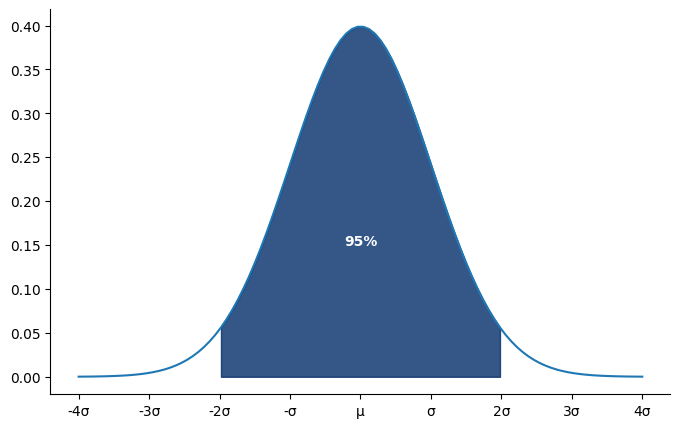

In [54]:
normal_auc(u=0, sd=1, fill_min=-2, fill_max=2)
plt.text(0,0.15, '95%', horizontalalignment='center', fontdict={'color':'white', 'weight':'bold'})
sns.despine(right=True, top=True)

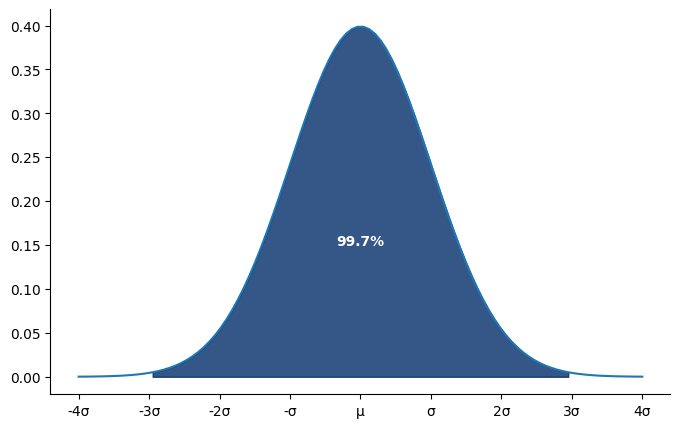

In [53]:
normal_auc(u=0, sd=1, fill_min=-3, fill_max=3)
plt.text(0,0.15, '99.7%', horizontalalignment='center', fontdict={'color':'white', 'weight':'bold'})
sns.despine(right=True, top=True)

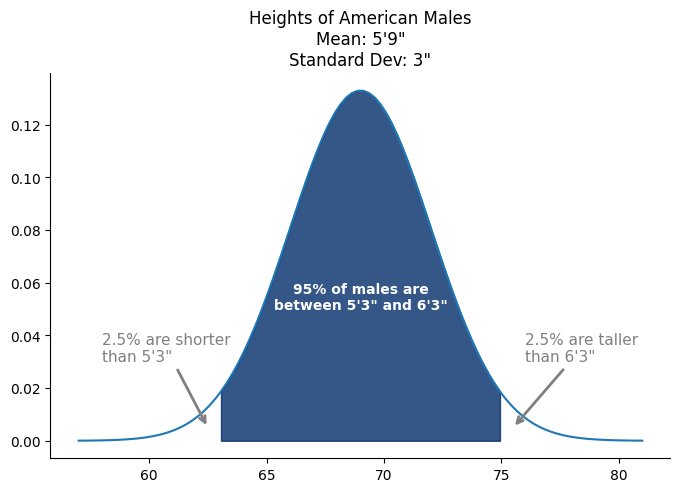

In [96]:
normal_auc(u=69, sd=3, fill_min=69-(3*2), fill_max=69+(3*2), title='Heights of American Males\nMean: 5\'9"\nStandard Dev: 3"')
plt.text(69,0.05, '95% of males are\nbetween 5\'3" and 6\'3"', horizontalalignment='center', fontdict={'color':'white', 'weight':'bold'})
plt.annotate('2.5% are taller\nthan 6\'3"', #add what we want 
            xy=(75.5, 0.005), xytext=(76, 0.03), # xy: The end point of the arrow (arrowhead position); xytext: The start point of the arrow (arrow tail position)
            arrowprops=dict(arrowstyle='->', color='grey', lw=2), #lw: linewidth in pixels
            fontsize=11, color='grey')
plt.annotate('2.5% are shorter\nthan 5\'3"', #add what we want 
            xy=(62.5, 0.005), xytext=(58, 0.03), # xy: The end point of the arrow (arrowhead position); xytext: The start point of the arrow (arrow tail position)
            arrowprops=dict(arrowstyle='->', color='grey', lw=2), #lw: linewidth in pixels
            fontsize=11, color='grey')
sns.despine(right=True, top=True)

# Standard Error

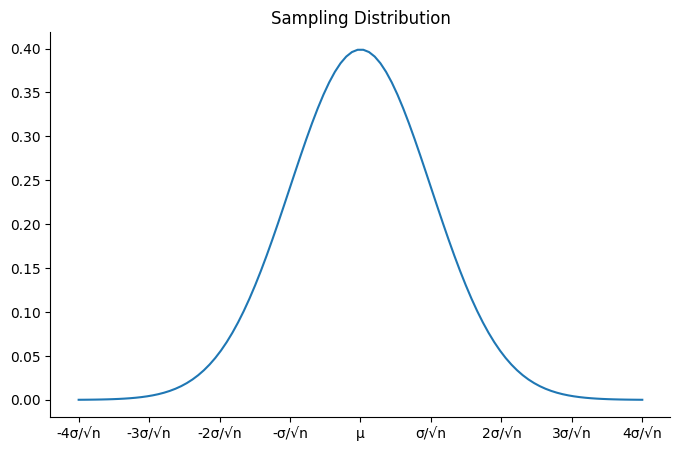

In [153]:
mn=-4
mx=4
x = np.linspace(mn, mx, 100)
y = stats.norm.pdf(x, loc=0, scale=1)
fig, ax = plt.subplots(figsize=(8, 5))
p=sns.lineplot(x=x, y=y).set_title('Sampling Distribution');
ax.set_xticks([-4, -3, -2, -1, 0, 1, 2, 3, 4])
ax.set_xticklabels(['-4\u03C3/\N{SQUARE ROOT}n', '-3\u03C3/\N{SQUARE ROOT}n', '-2\u03C3/\N{SQUARE ROOT}n', '-\u03C3/\N{SQUARE ROOT}n', 
                    '\u03bc', '\u03C3/\N{SQUARE ROOT}n','2\u03C3/\N{SQUARE ROOT}n','3\u03C3/\N{SQUARE ROOT}n', '4\u03C3/\N{SQUARE ROOT}n'])
sns.despine(right=True, top=True);

# Confidence Intervals

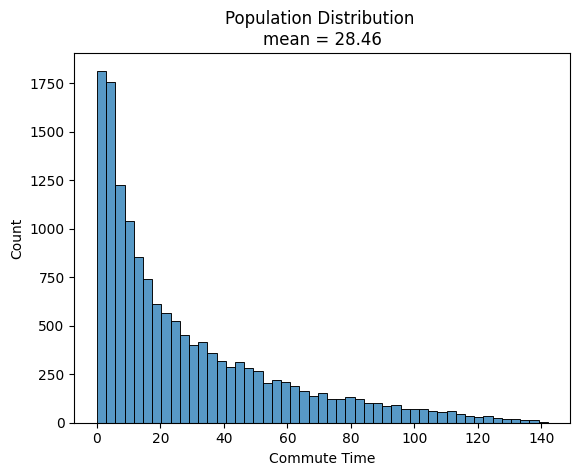

In [2]:
# Generate an array of multiple random numbers from a right-skewed distribution
n = 15000
# Right-skewed triangular distribution
data = [random.triangular(0, 12, 2)**2 for _ in range(n)] # min, max, mode
pop_mean=np.mean(data)

#population distribution
sns.histplot(x=data).set_title('Population Distribution \nmean = '+str(round(pop_mean,2)))
plt.xlabel('Commute Time');
#plt.axvline(x=pop_mean, color='crimson', linestyle='--', alpha=0.8);

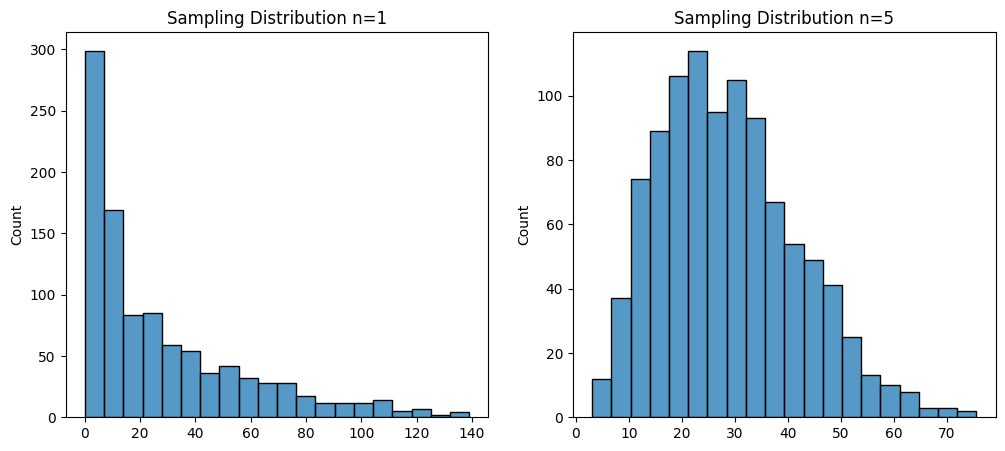

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for axi, n in enumerate([1,5]):
    d_sample={}
    for i in range(0,1000):
        sample = np.random.choice(data, size=n, replace=False)
        sample_mean=np.mean(sample)
        #sample_std=np.std(sample, ddof=1)
        #ci=conf_int_t(data=sample, conf_level=0.95)
        d_sample[i]={'sample_mean': sample_mean,
                     #'ci':ci
                    }
    x=[d_sample[i]['sample_mean'] for i in d_sample]   
    sns.histplot(x=x, ax=ax[axi]).set_title('Sampling Distribution n='+str(n));

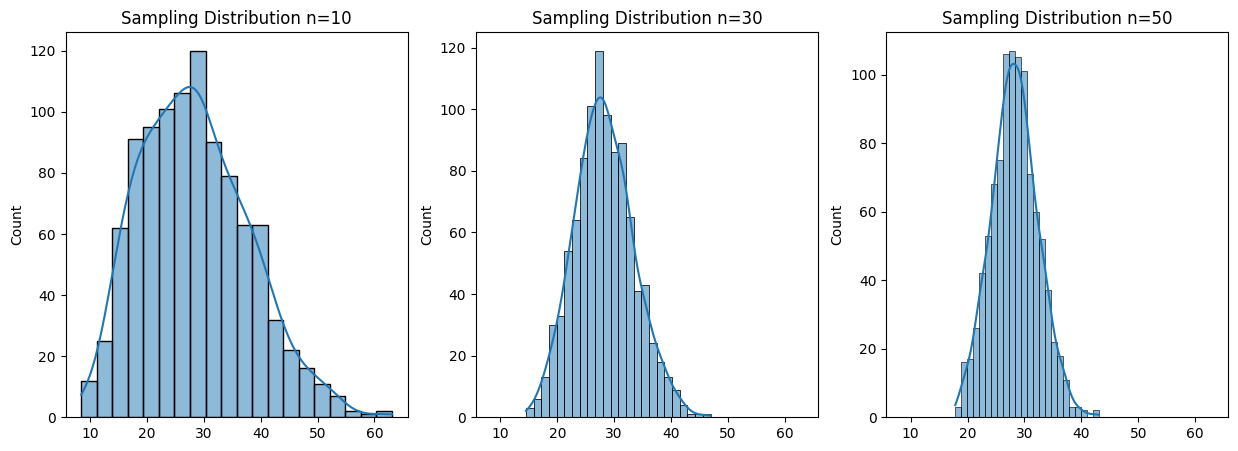

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharex=True)
for axi, n in enumerate([10, 30, 50]):
    d_sample={}
    for i in range(0,1000):
        sample = np.random.choice(data, size=n, replace=False)
        sample_mean=np.mean(sample)
        ci=conf_int_t_data(data=sample, conf_level=0.95)
        d_sample[i]={'sample_mean': sample_mean,
                     'ci':ci
                    }
    x=[d_sample[i]['sample_mean'] for i in d_sample]   
    sns.histplot(x=x, ax=ax[axi],kde=True).set_title('Sampling Distribution n='+str(n));

$$
\frac{\sigma}{\sqrt{n}}
$$

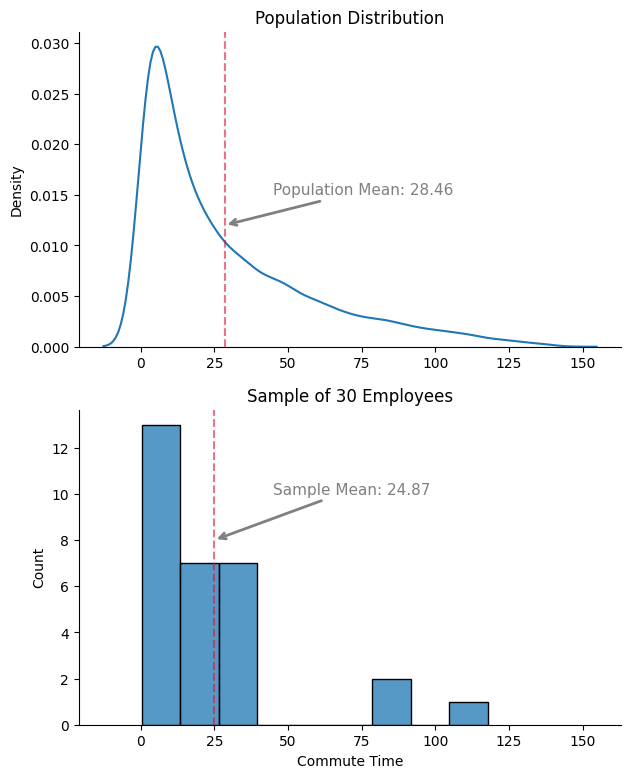

In [32]:
fig, ax = plt.subplots(2,1, figsize=(7, 9), sharex=True)
sns.despine(right=True, top=True)
#population
sns.kdeplot(x=data, ax=ax[0]).set_title('Population Distribution')
ax[0].axvline(x=np.mean(data),linestyle='--', color='crimson', alpha=0.6);
ax[0].xaxis.set_tick_params(which='both', labelbottom=True)
plt.xlabel('Commute Time');
ax[0].annotate('Population Mean: '+str(round(pop_mean,2)), #add what we want 
            xy=(pop_mean, 0.012), xytext=(45, 0.015), # xy: The end point of the arrow (arrowhead position); xytext: The start point of the arrow (arrow tail position)
            arrowprops=dict(arrowstyle='->', color='grey', lw=2), #lw: linewidth in pixels
            fontsize=11, color='grey')

#sample
sample = np.random.choice(data, size=30, replace=False)
sample_mean=np.mean(sample)
sns.histplot(x=sample, ax=ax[1]).set_title('Sample of 30 Employees')
ax[1].axvline(x=sample_mean,linestyle='--', color='crimson', alpha=0.6)
ax[1].annotate('Sample Mean: '+str(round(sample_mean,2)), #add what we want 
            xy=(sample_mean, 8), xytext=(45, 10), # xy: The end point of the arrow (arrowhead position); xytext: The start point of the arrow (arrow tail position)
            arrowprops=dict(arrowstyle='->', color='grey', lw=2), #lw: linewidth in pixels
            fontsize=11, color='grey');

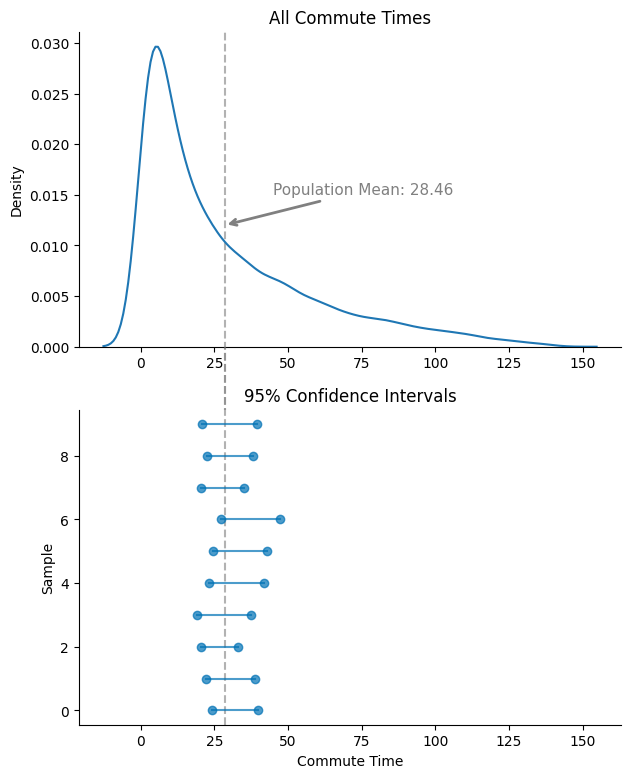

In [33]:
fig, ax = plt.subplots(2,1, figsize=(7, 9), sharex=True)
sns.despine(right=True, top=True)

#popultaion
sns.kdeplot(x=data, ax=ax[0]).set_title('All Commute Times');
ax[0].xaxis.set_tick_params(which='both', labelbottom=True)
#confidence intervals from sample
#ax[1].axvline(x=pop_mean, color='grey', linestyle='--')
ax[0].axvline(x=pop_mean, ymin=-1.2,ymax=1, zorder=0, clip_on=False, linestyle='--', color='grey', alpha=0.6)
ax[1].axvline(x=pop_mean, ymin=0,ymax=1.2, zorder=0, clip_on=False, linestyle='--', color='grey', alpha=0.6)
for i in range(0,10):
    ci=d_sample[i]['ci']
    ax[1].plot([ci[0], ci[1]], [i, i], '-o', color='#0072b5ff', alpha=0.7)
ax[1].set(ylabel='Sample', xlabel='Commute Time', title='95% Confidence Intervals')
ax[0].annotate('Population Mean: '+str(round(pop_mean,2)), #add what we want 
            xy=(pop_mean, 0.012), xytext=(45, 0.015), # xy: The end point of the arrow (arrowhead position); xytext: The start point of the arrow (arrow tail position)
            arrowprops=dict(arrowstyle='->', color='grey', lw=2), #lw: linewidth in pixels
            fontsize=11, color='grey');

In [78]:
df=pd.read_csv('data/citibike_201909.csv')
df.head()

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender
0,145,2019-09-01 00:00:37.6920,2019-09-01 00:03:03.0100,3640,Journal Square,40.733670,-74.062500,3206,Hilltop,40.731169,-74.057574,29303,Subscriber,1991,1
1,212,2019-09-01 00:03:00.6000,2019-09-01 00:06:33.3420,3194,McGinley Square,40.725340,-74.067622,3679,Bergen Ave,40.722104,-74.071455,29297,Subscriber,1993,2
2,569,2019-09-01 00:07:13.0020,2019-09-01 00:16:42.8610,3214,Essex Light Rail,40.712774,-74.036486,3184,Paulus Hook,40.714145,-74.033552,29435,Customer,1977,1
3,1380,2019-09-01 00:07:25.3350,2019-09-01 00:30:26.1640,3214,Essex Light Rail,40.712774,-74.036486,3792,Columbus Dr at Exchange Pl,40.716870,-74.032810,29509,Subscriber,1965,1
4,1346,2019-09-01 00:07:56.4670,2019-09-01 00:30:22.5440,3214,Essex Light Rail,40.712774,-74.036486,3792,Columbus Dr at Exchange Pl,40.716870,-74.032810,29226,Subscriber,1968,2


In [79]:
#get top 10 stations by trip duration
stations=df.groupby(['start station name']).tripduration.mean().reset_index(name='tripduration').sort_values(by='tripduration', ascending=False).head(10)['start station name']
#create subset df of only top 10 stations
df_bar=df.loc[df['start station name'].isin(stations)]
#create column to order by
d_map={s:i for i, s in enumerate(stations)}
station_order=df_bar['start station name'].map(d_map)
df_bar['station_order']=station_order
#order df
df_bar=df_bar.sort_values(by='station_order')

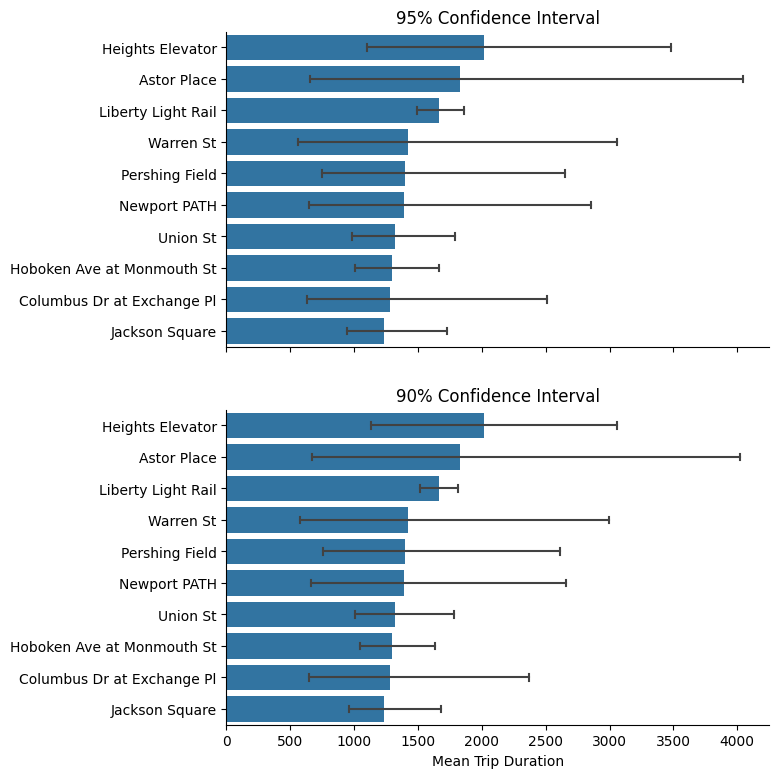

In [107]:
fig, ax = plt.subplots(2,1, figsize=(7, 9), sharex=True, sharey=True)
sns.despine(right=True, top=True)

#errorbar=('ci', 95), capsize=0.2, 

#95% ci
sns.barplot(data=df_bar, y='start station name', x='tripduration',errorbar=('ci', 95), capsize=0.2, err_kws={'linewidth': 1.5}, ax=ax[0])
ax[0].set(ylabel='',title='95% Confidence Interval')

#90% ci
sns.barplot(data=df_bar, y='start station name', x='tripduration', errorbar=('ci', 90), capsize=0.2, err_kws={'linewidth': 1.5}, ax=ax[1])
ax[1].set(ylabel='', xlabel='Mean Trip Duration', title='90% Confidence Interval');

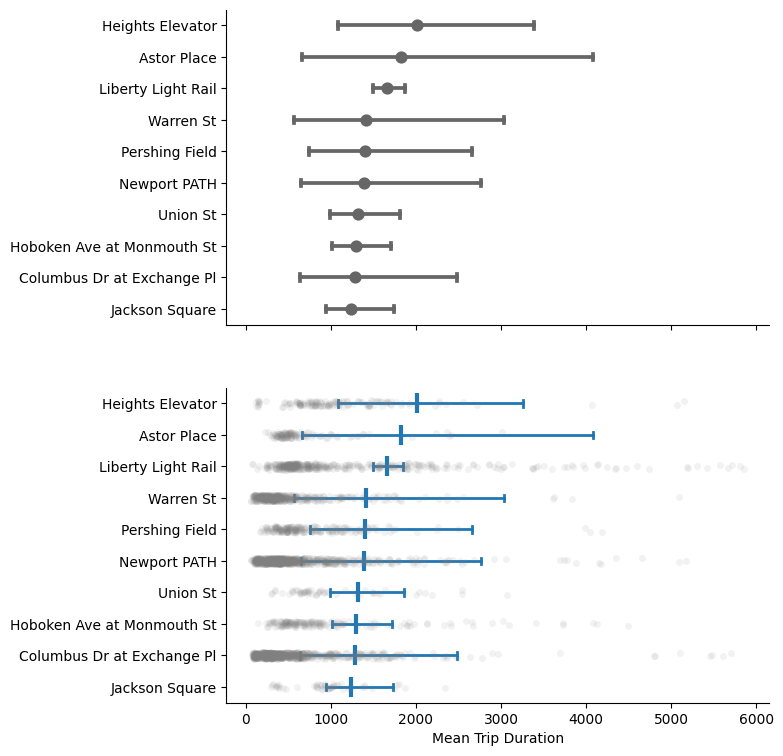

In [164]:
fig, ax = plt.subplots(2,1, figsize=(7, 9), sharex=True, sharey=True)
sns.despine(right=True, top=True)

#points with errorbars
sns.pointplot(data=df_bar,y='start station name', x='tripduration', linestyle='none', capsize=.2,
             color='0.4', ax=ax[0])
ax[0].set(ylabel='', xlabel='');

#points with stripplot
#df_bar.loc[df_bar.tripduration<5000]
sns.stripplot(
    data=df_bar.loc[df_bar.tripduration<6000].sample(frac=0.4), y='start station name', x='tripduration', 
    dodge=False, alpha=.1, legend=False, color='grey', ax=ax[1])
sns.pointplot(
    data=df_bar, y='start station name', x='tripduration',
    linestyle="none", errorbar=("ci", 95),capsize=.2, err_kws={'linewidth': 2},
    marker='|', markersize=15, markeredgewidth=3, ax=ax[1]
)
ax[1].set(ylabel='', xlabel='Mean Trip Duration');

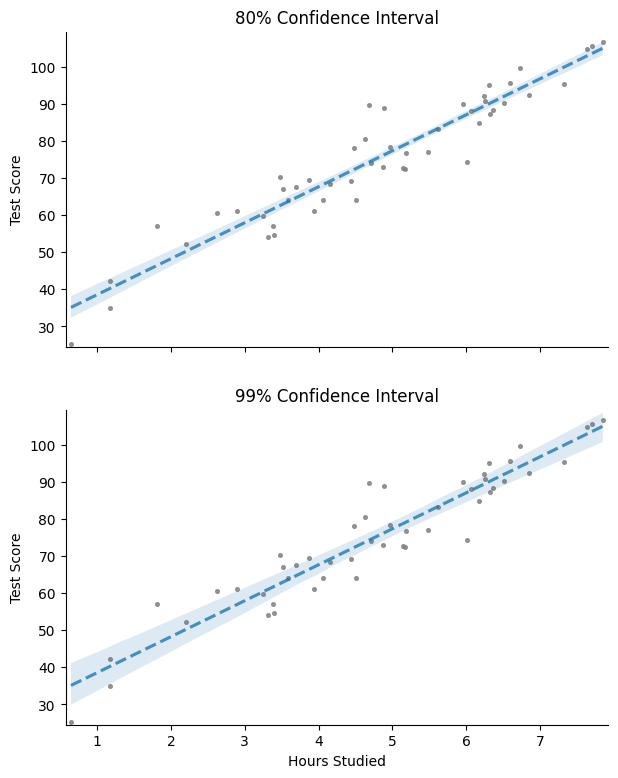

In [188]:
df=pd.read_csv('data/study_hours_vs_test_scores.csv')


fig, ax = plt.subplots(2,1, figsize=(7, 9), sharex=True, sharey=True)
sns.despine(right=True, top=True)

#95%ci
sns.regplot(data=df,x='hours_studied', y='test_score', scatter_kws={'s':7, 'color':'grey'}, 
            line_kws={'linestyle':'--', 'alpha':0.8}, ci=80, ax=ax[0])
ax[0].set(xlabel='', ylabel='Test Score', title='80% Confidence Interval')
ax[0].margins(x=0.01, y=0.01);

#95%ci
sns.regplot(data=df,x='hours_studied', y='test_score', scatter_kws={'s':7, 'color':'grey'}, 
            line_kws={'linestyle':'--', 'alpha':0.8}, ci=99, ax=ax[1])
ax[1].set(xlabel='Hours Studied', ylabel='Test Score', title='99% Confidence Interval')
ax[1].margins(x=0.01, y=0.01);

In [2]:
ticker=['QQQM', 'NVDA']
data = yf.download(ticker, period='2y')
#calculate daily returns
df=pd.DataFrame(columns=['date','qqqm_close', 'qqqm_return', 'nvd_close', 'nvd_return'])
qqqm_prev=[]
qqqm_change=[np.NaN]
nvd_prev=[]
nvd_change=[np.NaN]

for index, row in data.iterrows():
    qqqm_prev.append(row['Close']['QQQM'])
    nvd_prev.append(row['Close']['NVDA'])
    if len(qqqm_prev)>1:
        qqqm_chg=(row['Close']['QQQM']-qqqm_prev[-2])/qqqm_prev[-2]
        qqqm_change.append(qqqm_chg*100)
        nvd_chg=(row['Close']['NVDA']-nvd_prev[-2])/nvd_prev[-2]
        nvd_change.append(nvd_chg*100)
    df.loc[len(df)]=[index, row['Close']['QQQM'],qqqm_change[-1],row['Close']['NVDA'], nvd_change[-1]]
df=df.iloc[:-1]
df.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  2 of 2 completed


,date,qqqm_close,qqqm_return,nvd_close,nvd_return
0,2024-02-26,177.581619,NaN,79.047966,NaN
1,2024-02-27,177.996582,0.233674,78.657181,-0.494365
2,2024-02-28,177.038223,-0.538414,77.619751,-1.318926
3,2024-02-29,178.520248,0.837122,79.067955,1.865767
4,2024-03-01,181.276718,1.544066,82.233185,4.003177


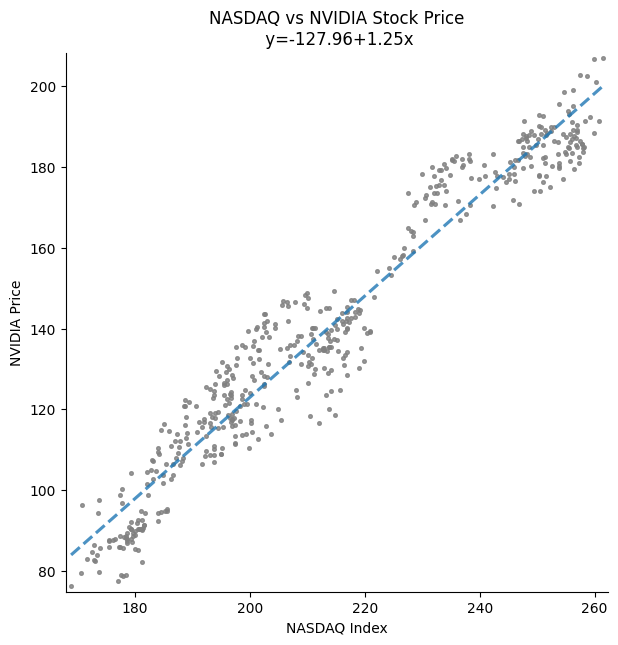

In [3]:
fig, ax = plt.subplots(figsize=(7, 7), sharex=True, sharey=True)
sns.despine(right=True, top=True)

#95%ci
sns.regplot(data=df,x='qqqm_close', y='nvd_close', scatter_kws={'s':7, 'color':'grey'}, 
            line_kws={'linestyle':'--', 'alpha':0.8}, ci=None, ax=ax)

slope, intercept, r_value, p_value, std_err = stats.linregress(df.qqqm_close.tolist(), df.nvd_close)

ax.set(xlabel='NASDAQ Index', ylabel='NVIDIA Price', title=f'NASDAQ vs NVIDIA Stock Price\n y={round(intercept,2)}+{round(slope,2)}x')
ax.margins(x=0.01, y=0.01);

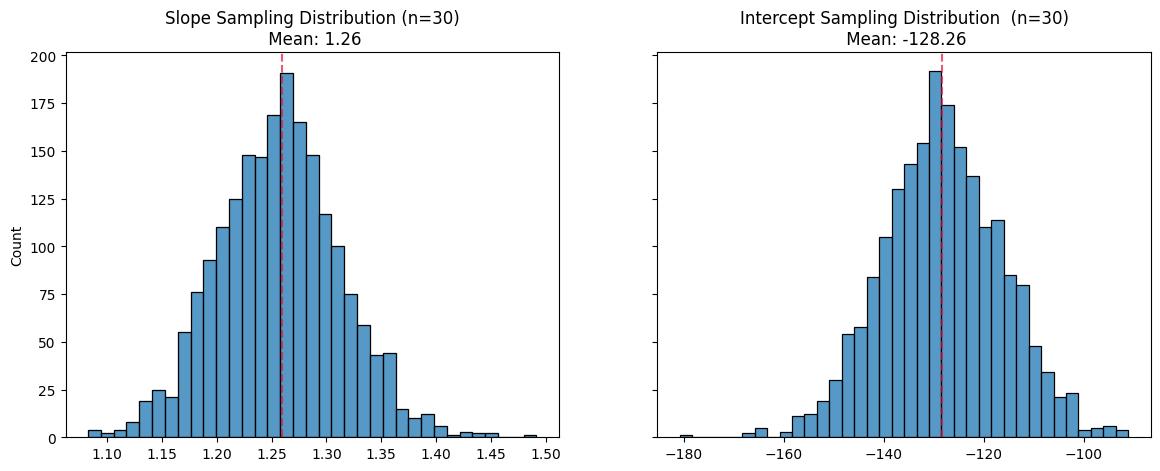

In [218]:
slp=[]
y_int=[]
#slope/intercept simulation
for i in range(2000):
    d=df.sample(n=30)
    slope, intercept, r_value, p_value, std_err = stats.linregress(d.qqqm_close.tolist(), d.nvd_close)
    slp.append(slope)
    y_int.append(intercept)
    
fig, ax = plt.subplots(1,2, figsize=(14,5), sharex=False, sharey=True)

#slope
sns.histplot(x=slp, ax=ax[0])
slp_mean=round(np.mean(slp),2)
ax[0].axvline(x=slp_mean, color='crimson', alpha=0.7, linestyle='--')
ax[0].set(title=f'Slope Sampling Distribution (n=30)\n Mean: {slp_mean}')

#intercept
sns.histplot(x=y_int, ax=ax[1])
int_mean=round(np.mean(y_int),2)
ax[1].axvline(x=int_mean, color='crimson', alpha=0.7, linestyle='--')
ax[1].set(title=f'Intercept Sampling Distribution  (n=30)\n Mean: {int_mean}');